### 1. Import modules and functions

In [1]:
# 1) 基础工具
import os
import math
import warnings
import importlib
import numpy as np
import pickle as pk
import pandas as pd
from datetime import datetime
from scipy.odr import Model, Data, ODR

# 2) 绘图工具
import matplotlib.pyplot as plt
import seaborn as sns

# 3) 模型预测
import lightgbm
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# 4) 参数搜索与模型评估
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

warnings.filterwarnings("ignore")

In [2]:
def dump_pk(obj, fn):
	""" 
	Write python object to pickle file.
	
	Parameters
	----------
	obj: object to be saved

	fn: target output directory
	"""
	with open(fn, 'wb') as f:
		pk.dump(obj, f, protocol = pk.HIGHEST_PROTOCOL)
	return

In [3]:
def cal_rmse(y_true, y_pred):
	""" 
	Calculate the rmse between y_true and y_pred.
		
	Parameters
	----------
	y_true: list_like

	y_pred: list_like

	"""
	y_true = np.array(y_true)
	y_pred = np.array(y_pred)
	return np.sqrt(np.mean((y_true - y_pred)**2))

In [4]:
# def f(p, x):
#     return (p[0] * x) + p[1]

def orthoregress(x, y):
    mod = Model(f)
    dat = Data(x, y)
    od  = ODR(dat, mod, beta0=[0.0, 1.0])
    out = od.run()
    return out

### 2. Data preparation

In [5]:
with open("./data/training_input/train_D_for_lightgbm_2017.pk", "rb") as f:
    train_D = pk.load(f)
    
with open("./data/training_input/test_D_for_lightgbm_2018.pk", "rb") as f:
    test_D = pk.load(f)

In [6]:
# Split train and test data
train_X, train_y = train_D.copy(), train_D["obs_o3"]
test_X, test_y = test_D.copy(), test_D["obs_o3"]

# Remove labels and unrequired columns
train_X.pop("obs_o3");
test_X.pop("obs_o3");

train_X.pop("SID");
test_X.pop("SID");

# Seclect features
columns = train_X.columns

columns = ['geos_o3', 'NOx', 'VOC', 'CO',
           'mon', 'hour', 'landuse', 'topo', 'gdp', 'pop',
           't2m', 'u10m', 'v10m', 'ssrd', 'msl', 'rh', 'uwnd_850hpa', 'vwnd_850hpa']

##### 

In [ ]:

import lightgbm

# 1) Create a model
model = lightgbm.LGBMRegressor(random_state=1)

# 2) Train the model
fitted_model = model.fit(X, y)

# 3) Make predictions
predicted_y = fitted_model.predict(X)


In [ ]:

import lightgbm

# 1) Split training and test data
X_train, X_test, y_train, y_test = train_test_split(
                                X, y, test_size=0.3)

# 2) Create the model
model = lightgbm.LGBMRegressor(random_state=1)

# 3) Train the model on training data
fitted_model = model.fit(X_train, y_train)

# 4) Make predictions on test data
predicted_y_test = fitted_model.predict(X_test)

# 5) Model evaluation
rmse = cal_rmse(predicted_y_test, obs_y)
r2 = cal_r2(predicted_y_test, obs_y)

print(rmse, r2)


In [ ]:
# 1) create a model
model = lightgbm.LGBMRegressor(random_state=1, n_jobs=-1, force_row_wise=True)

### 3. Train and tune odel

In [7]:
# 1) create a model
model = lightgbm.LGBMRegressor(random_state=1, n_jobs=-1, force_row_wise=True)

param_grid = { 
                "model__max_depth": [15],
                # "model__num_leaves": [50, 80, 100],
                "model__num_leaves": [50],
                # 'model__learning_rate': [0.1], 
                "model__importance_type": ["gain"],
             }

my_pipeline = Pipeline(steps=[
                          ("model", model),
                         ])

In [8]:
# 2) parameter tuning
grid_search = GridSearchCV(my_pipeline, param_grid, cv=10, n_jobs=-1)
grid_search.fit(train_X[columns], train_y)

grid_search.best_estimator_, grid_search.best_score_

[LightGBM] [Info] Total Bins 3552
[LightGBM] [Info] Number of data points in the train set: 8900160, number of used features: 18
[LightGBM] [Info] Start training from score 63.285129


(Pipeline(steps=[('model',
                  LGBMRegressor(force_row_wise=True, importance_type='gain',
                                max_depth=15, n_jobs=-1, num_leaves=50,
                                random_state=1))]),
 0.5980215733339015)

In [9]:
# 3) fit final models with searched best parameters
best_params = dict(zip([key[7::] for key in grid_search.best_params_.keys()], grid_search.best_params_.values()))

best_train_model = lightgbm.LGBMRegressor(**best_params, random_state=1,).fit(train_X[columns], train_y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3552
[LightGBM] [Info] Number of data points in the train set: 8900160, number of used features: 18
[LightGBM] [Info] Start training from score 63.285129


In [10]:
fi = pd.Series(best_train_model.feature_importances_, index=train_X[columns].columns)

fi.sort_values(ascending=False).index

Index(['geos_o3', 'hour', 'rh', 'ssrd', 'v10m', 'topo', 'mon', 't2m', 'u10m',
       'pop', 'gdp', 'VOC', 'CO', 'NOx', 'msl', 'vwnd_850hpa', 'uwnd_850hpa',
       'landuse'],
      dtype='object')

[LightGBM] [Info] Total Bins 3551
[LightGBM] [Info] Number of data points in the train set: 8010144, number of used features: 18
[LightGBM] [Info] Start training from score 62.917601
[LightGBM] [Info] Total Bins 3600
[LightGBM] [Info] Number of data points in the train set: 8010144, number of used features: 18
[LightGBM] [Info] Start training from score 63.934016
[LightGBM] [Info] Total Bins 3599
[LightGBM] [Info] Number of data points in the train set: 8010144, number of used features: 18
[LightGBM] [Info] Start training from score 62.748211
[LightGBM] [Info] Total Bins 3557
[LightGBM] [Info] Number of data points in the train set: 8010144, number of used features: 18
[LightGBM] [Info] Start training from score 63.253817
[LightGBM] [Info] Total Bins 3551
[LightGBM] [Info] Number of data points in the train set: 8010144, number of used features: 18
[LightGBM] [Info] Start training from score 63.045004
[LightGBM] [Info] Total Bins 3553
[LightGBM] [Info] Number of data points in the trai

### 4. Model evaluation

In [38]:
predict_train_y = best_train_model.predict(train_X[columns])

df_train = pd.DataFrame(index=train_y.index)

df_train["obs_train_y"]     = train_y
df_train["gchp_train_y"]    = train_X["geos_o3"]
df_train["predict_train_y"] = predict_train_y

In [43]:
print("### Training data ###")
print("\n ========Correlation coefficient=======" )
print(df_train.corr()**2)

print("\n@ RMSE: {}".format(round(cal_rmse(df_train["obs_train_y"], df_train["predict_train_y"]), 2)))

### Training data ###

 ========Correlation coefficient=======
                 obs_train_y  gchp_train_y  predict_train_y
obs_train_y         1.000000      0.401349         0.664532
gchp_train_y        0.401349      1.000000         0.643456
predict_train_y     0.664532      0.643456         1.000000

@ RMSE: 26.4


In [40]:
predict_test_y = best_train_model.predict(test_X[columns])

df_test = pd.DataFrame(index=test_y.index)

df_test["obs_test_y"]     = test_y
df_test["gchp_test_y"]    = test_X["geos_o3"]
df_test["predict_test_y"] = predict_test_y

In [46]:
print("### Test data ###")
print("\n========Correlation coefficient=======" )
print(df_test.corr()**2)

print("\n@ RMSE: {}".format(round(cal_rmse(df_test["obs_test_y"], df_test["predict_test_y"]), 2)))

### Test data ###

========Correlation coefficient=======
                obs_test_y  gchp_test_y  predict_test_y
obs_test_y        1.000000     0.418344        0.667430
gchp_test_y       0.418344     1.000000        0.632779
predict_test_y    0.667430     0.632779        1.000000

@ RMSE: 25.79


In [17]:
# Save well-trained model
dump_pk(best_train_model, "./data/model_output/lightgbm_best_train_model.pk")

# Save data
dump_pk(df_test, "./data/model_output/lightgbm_prediction.pk")

### 5. Plot

In [35]:
df = pd.DataFrame(columns=["obs_o3", "gchp_o3", "lightgbm_o3"])

df["obs_o3"] = df_test["obs_test_y"]
df["gchp_o3"] = df_test["gchp_test_y"] * 2 # unit convertion (ppb->ug/m3)
df["lightgbm_o3"] = df_test["predict_test_y"]

#### (1) Plot feature importance plot

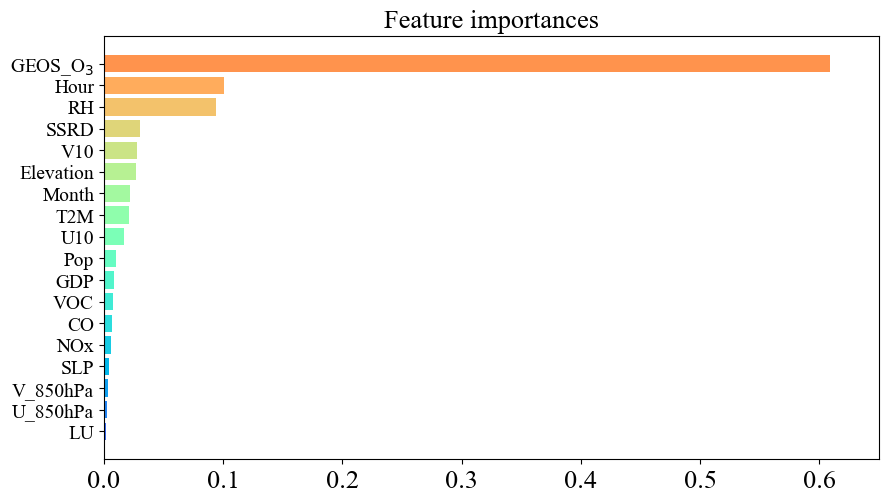

In [31]:
# 1) plot feature importance plot

import seaborn as sns

%matplotlib inline 

plt.rcParams['font.sans-serif'] = ['Times New Roman'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['font.size'] = 19

data={"feature_names": train_X[columns].columns, "feature_importance": fi/fi.sum()}
fi_df = pd.DataFrame(data)

# sort the DataFrame in order decreasing feature importance
fi_df.sort_values(by=["feature_importance"], ascending=False, inplace=True)

# define size of bar plot
fig, axe = plt.subplots(figsize=(10, 5.5))

# Plot Searborn bar chart
my_cmap = plt.get_cmap("rainbow_r")
y_pos = np.arange(len(fi_df["feature_names"]))
axe.barh(y_pos, fi_df["feature_importance"][::-1], color=my_cmap(range(220, 10, -10)))

# add chart labels
plt.xlabel("")
plt.xlim(0, 0.65)
plt.yticks(y_pos, fi_df["feature_names"][::-1].replace("geos_o3", "GEOS_O${_3}$")\
                      .replace("lon", "Lon")\
                      .replace("lat", "Lat")\
                      .replace("hour", "Hour")\
                      .replace("mon", "Month")\
                      .replace("mon_mean", "Monthly_O${_3}$")\
                      .replace("hour_mean", "Hourly_O${_3}$")\
                      .replace("ssrd", "SSRD")\
                      .replace("msl", "SLP")\
                      .replace("t2m", "T2M")\
                      .replace("rh", "RH")\
                      .replace("u10m", "U10")\
                      .replace("v10m", "V10")\
                      .replace("uwnd_850hpa", "U_850hPa")\
                      .replace("vwnd_850hpa", "V_850hPa")\
                      .replace("topo", "Elevation")\
                      .replace("landuse", "LU") \
                      .replace("pop", "Pop")\
                      .replace("gdp", "GDP"),
                      fontsize=14)

plt.title("Feature importances", fontsize=19)


# 设置图号
text_font = {"size" : 24, "color" : "k", "family": "Times New Roman"}
axe.text(.93,.05,"", transform=axe.transAxes, fontdict=text_font, zorder=4);

plt.savefig("./pic/Feature_importance.png", dpi=600)

#### (2) LightGBM Performance RMSE and R2

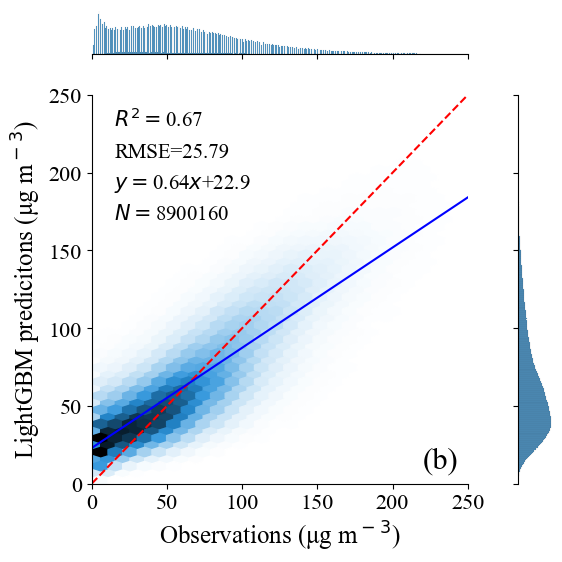

In [32]:
x = df["obs_o3"].values.ravel()
y = df["lightgbm_o3"].values.ravel()

model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

r2 = model.score(x.reshape(-1, 1), y)
rmse = round(cal_rmse(x, y), 2)

N = len(df)

x2 = np.linspace(0, 400)
y2 = x2

A1 = model.coef_[0]
B1 = model.intercept_
y3 = A1 * x2 + B1

plt.rcParams["font.family"] = "Times New Roman"

sns.jointplot(data=df, x="obs_o3", y="lightgbm_o3", kind="hex")
plt.plot(x2, y2, color="r", linewidth=1.5, linestyle="--")
plt.plot(x2, y3, color="b", linewidth=1.5, linestyle="-")

plt.ylim(0, 250)
plt.xlim(0, 250)

# 设置添加信息
fontdict = {"size" : 15, "color" : "k", "family": "Times New Roman"}
plt.text(15, 230, r"$R^2=$"+str(round(r2, 2)), fontdict=fontdict)
plt.text(15, 210, r"RMSE="+str(rmse), fontdict=fontdict)
plt.text(15, 190, r"$y=$"+str(round(A1, 2))+"$x$"+"+"+str(round(B1,2)), fontdict=fontdict)
plt.text(15, 170, r"$N=$"+str(N), fontdict=fontdict)

# 设置图号
text_font = {"size" : 22, "color" : "k", "family": "Times New Roman"}
plt.text(220, 10, "(b)", fontdict=text_font, zorder=4);

text_font = {"size" : 18, "color" : "k", "family": "Times New Roman"}
plt.xlabel('Observations (\u03bcg m${^-}$${^3}$)', fontdict=text_font)
plt.ylabel('LightGBM predicitons (\u03bcg m${^-}$${^3}$)', fontdict=text_font)

plt.tick_params(axis="both", labelsize=16)
plt.tight_layout()

plt.savefig("./pic/Fig1_density_scatter_plot_of_hourly_obs_ml_o3.png", dpi=600) 

#### (3) GEOS-Chem RMSE and R2

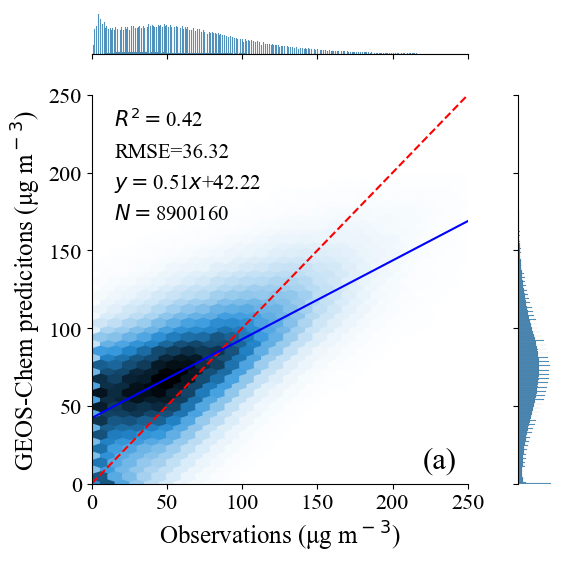

In [33]:
x = df["obs_o3"].values.ravel()
y = df["gchp_o3"].values.ravel()

model = LinearRegression()
model.fit(x.reshape(-1, 1), y)

r2 = model.score(x.reshape(-1, 1), y)
rmse = round(cal_rmse(x, y), 2)

N = len(df)

x2 = np.linspace(0, 400)
y2 = x2

A1 = model.coef_[0]
B1 = model.intercept_
y3 = A1 * x2 + B1

plt.rcParams["font.family"] = "Times New Roman"

sns.jointplot(data=df, x="obs_o3", y="gchp_o3", kind="hex")
plt.plot(x2, y2, color="r", linewidth=1.5, linestyle="--")
plt.plot(x2, y3, color="b", linewidth=1.5, linestyle="-")

plt.ylim(0, 250)
plt.xlim(0, 250)

# 设置添加信息
fontdict = {"size" : 15, "color" : "k", "family": "Times New Roman"}
plt.text(15, 230, r"$R^2=$"+str(round(r2, 2)), fontdict=fontdict)
plt.text(15, 210, r"RMSE="+str(rmse), fontdict=fontdict)
plt.text(15, 190, r"$y=$"+str(round(A1, 2))+"$x$"+"+"+str(round(B1,2)), fontdict=fontdict)
plt.text(15, 170, r"$N=$"+str(N), fontdict=fontdict)

# 设置图号
text_font = {"size" : 22, "color" : "k", "family": "Times New Roman"}
plt.text(220, 10, "(a)", fontdict=text_font, zorder=4);

text_font = {"size" : 18, "color" : "k", "family": "Times New Roman"}
plt.xlabel('Observations (\u03bcg m${^-}$${^3}$)', fontdict=text_font)
plt.ylabel('GEOS-Chem predicitons (\u03bcg m${^-}$${^3}$)', fontdict=text_font)

plt.tick_params(axis="both", labelsize=16)
plt.tight_layout()

plt.savefig("./pic/Fig1_density_scatter_plot_of_hourly_obs_gchp_o3.png", dpi=600) 

##### 

### 6. Save data

In [37]:
# Save well-trained model
dump_pk(best_train_model, "./data/model_output/lightgbm_best_train_model.pk")

# Save data
dump_pk(df, "./data/model_output/lightgbm_prediction.pk")